# `plotroads!` Demonstration

This notebook demonstrates the `plotroads!` function for overlaying road networks on geographic maps with FCLASS-based styling inspired by OSM Carto.

## Features
- FCLASS-based road class differentiation with muted OSM Carto hues
- Two-pass casing (outline effect) at close zoom for visual clarity
- Adaptive styling based on zoom level (latitude span)
- Optional connector visibility
- Customizable via returned handles
- Unified styling for FAF5 and OSM roads at the same FCLASS
- Compatible with both CairoMakie and GLMakie backends

## Setup

This notebook uses the local development version of Logjam by directly loading the source files.

**Important:** Run the cells below in order.

In [3]:
# Load dependencies
using GeoMakie, CairoMakie
using DataFrames

In [4]:
# Load Logjam directly from source (development mode)
logjam_src = joinpath(@__DIR__, "..", "src", "Logjam.jl")
println("Loading Logjam from: $logjam_src")
include(logjam_src)

# Import Logjam functions
import .Logjam: faf5links, faf5nodes, makemap, plotroads!, cropnetwork, 
                addconnectors, usplace, st2fips, aligntext
import DataFrames: nrow, filter

println("✓ Logjam loaded successfully with plotroads! function")

Loading Logjam from: C:\Users\kay\Documents\cdev\Logjam\examples\..\src\Logjam.jl
✓ Logjam loaded successfully with plotroads! function


## Example 1: Basic CONUS Road Network

Display the FAF5 road network at continental US scale. At this wide zoom (latspan > 20°), roads render as minimal single lines with faint hue tints.

In [ ]:
# Load FAF5 data
dfL, dfN = faf5links(), faf5nodes()

# Create base map
fig, ax = makemap(region=:CUS)

# Overlay roads
handles = plotroads!(ax, dfL, dfN)

println("Handle keys: $(collect(keys(handles)))")
println("Interstate fill linewidth: $(handles[:fill_1].linewidth[])")

fig

## Example 2: Zoom-Responsive Styling

The same network shows subtle hue tints at regional zoom (10-20° latspan) — single-line rendering without casings.

In [ ]:
# Regional view: North Carolina and surrounding states
x_region = [-85, -75]
y_region = [33, 37]

fig, ax = makemap(x_region, y_region)
handles = plotroads!(ax, dfL, dfN)

println("Regional view (no casings at this zoom):")
println("  Handle keys: $(collect(keys(handles)))")
println("  Has casings: $(any(k -> startswith(string(k), "casing"), keys(handles)))")

fig

## Example 3: City-Scale Detail

At city scale (latitude span < 10°), roads are rendered with full two-pass casing: a wider darker outline drawn first, then a narrower lighter fill on top. Road classes are distinguished by muted OSM Carto hues — blue for interstates, green for freeways, warm yellow for arterials.

In [ ]:
# Crop to North Carolina for faster rendering
x_nc = [-84.5, -75.5]
y_nc = [33.8, 36.6]
dfL_nc, dfN_nc = cropnetwork(dfN, dfL, x_nc, y_nc)

println("Cropped network: $(nrow(dfL_nc)) links, $(nrow(dfN_nc)) nodes")

# City view: Raleigh-Durham area
x_city = [-79.2, -78.5]
y_city = [35.6, 36.2]

fig, ax = makemap(x_city, y_city)
handles = plotroads!(ax, dfL_nc, dfN_nc)

println("City-scale view (with casings):")
println("  Handle keys: $(collect(keys(handles)))")
println("  Interstate fill: $(handles[:fill_1].linewidth[])")

fig

## Example 4: Adding Demand Point Connectors

Add connector links from demand points to the road network. Connectors are hidden by default but can be shown with `show_connectors=true`.

Network with connectors: 32679 links
Handles without connectors: 2
Handles with connectors: 3


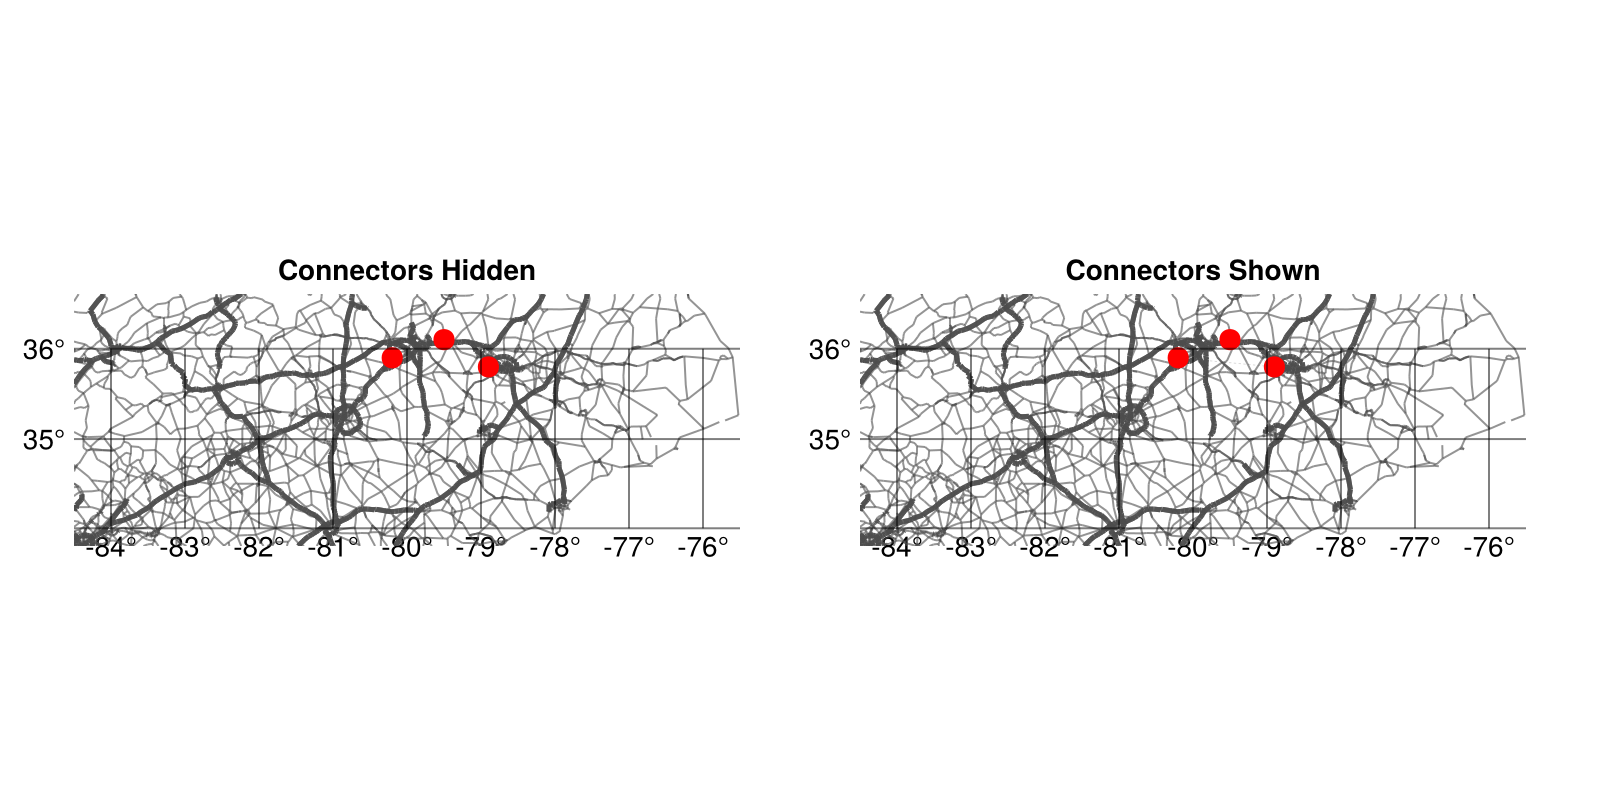

In [8]:
# Define warehouse locations in NC
warehouses_lon = [-78.9, -80.2, -79.5]
warehouses_lat = [35.8, 35.9, 36.1]

# Add connectors
dfL_conn, dfN_conn = addconnectors(dfL_nc, dfN_nc, warehouses_lon, warehouses_lat)

println("Network with connectors: $(nrow(dfL_conn)) links")

# Plot WITHOUT connectors (default)
fig1 = Figure(size=(800, 400))
ax1 = GeoAxis(fig1[1, 1], dest="+proj=merc", title="Connectors Hidden")
ax1.limits = (x_nc, y_nc)
h1 = plotroads!(ax1, dfL_conn, dfN_conn; show_connectors=false)
scatter!(ax1, warehouses_lon, warehouses_lat, color=:red, markersize=15, label="Warehouses")
println("Handles without connectors: $(length(h1))")

# Plot WITH connectors
ax2 = GeoAxis(fig1[1, 2], dest="+proj=merc", title="Connectors Shown")
ax2.limits = (x_nc, y_nc)
h2 = plotroads!(ax2, dfL_conn, dfN_conn; show_connectors=true)
scatter!(ax2, warehouses_lon, warehouses_lat, color=:red, markersize=15, label="Warehouses")
println("Handles with connectors: $(length(h2))")

fig1

## Example 5: Customizing Road Appearance

Returned handles are a `Dict{Symbol, Any}` with named keys like `:fill_1` (interstate fill), `:casing_1` (interstate casing), `:connector`, etc. This makes customization explicit and zoom-independent.

In [ ]:
# Create map
fig, ax = makemap(x_nc, y_nc)
handles = plotroads!(ax, dfL_conn, dfN_conn; show_connectors=true)

# Customize using named keys
println("Available handles: $(collect(keys(handles)))")

# Example: make interstate fills darker blue
handles[:fill_1].color = :darkblue
handles[:fill_1].alpha = 0.8

# Example: make connector more visible
if haskey(handles, :connector)
    handles[:connector].color = (:red, 0.7)
    handles[:connector].linewidth = 1.5
end

# Add warehouse markers
scatter!(ax, warehouses_lon, warehouses_lat, color=:red, markersize=20, 
         marker=:rect, label="Warehouses")

fig

## Example 6: Combining with Cities

Demonstrate integration with other Logjam functions to create a complete map.

In [ ]:
# Get major NC cities
cities = filter(r -> (r.STFIP == st2fips(:NC)) && (r.POP > 100_000), usplace())
x_cities, y_cities = cities.LON, cities.LAT
names_cities = cities.NAME

# Create comprehensive map
fig, ax = makemap(x_nc, y_nc)

# Add roads — FCLASS-based styling applied automatically
handles = plotroads!(ax, dfL_nc, dfN_nc)

# Add cities
scatter!(ax, x_cities, y_cities, color=:darkred, markersize=12)
text!(ax, x_cities, y_cities, text=names_cities; aligntext(x_cities, y_cities)...,
      fontsize=10, color=:black)

fig

## Styling Reference

Roads are styled by FCLASS tier with muted OSM Carto hues. Styling adapts to three zoom levels:

**FCLASS Tiers:**

| Tier | FCLASS | Road Type | Fill Color | Casing Color |
|------|--------|-----------|------------|--------------|
| 1 | 1 | Interstate | Muted blue (0.60, 0.70, 0.82) | Dark blue (0.35, 0.42, 0.52) |
| 2 | 2 | Freeway | Muted green (0.72, 0.82, 0.72) | Dark green (0.45, 0.55, 0.40) |
| 3 | 3 | Arterial | Warm yellow (0.90, 0.82, 0.70) | Brown (0.65, 0.52, 0.30) |
| 4 | 4 | Collector | Pale yellow (0.92, 0.90, 0.80) | Olive (0.60, 0.58, 0.48) |
| 5 | 5-7 | Local | Near-white (0.95, 0.95, 0.95) | Gray (0.65, 0.65, 0.65) |

**Zoom-Adaptive Rendering:**

| Latitude Span | Scale | Rendering | Linewidths (Tier 1 → 5) | Alpha (Tier 1 → 5) |
|---------------|-------|-----------|--------------------------|---------------------|
| > 20° | CONUS | Single-line, faint | 0.4 → 0.1 | 0.3 → 0.1 |
| 10-20° | Regional | Single-line, hue tints | 1.2 → 0.3 | 0.5 → 0.25 |
| < 10° | City/Metro | Two-pass casing + fill | 1.8 → 0.8 (fill), +1.2 (casing) | 0.8 → 0.4 |

Connectors use fixed styling: lw=0.3, alpha=0.15, dashed, gray.

## Function Signature

```julia
plotroads!(ax::GeoAxis, dfL::DataFrame, dfN::DataFrame;
           show_connectors::Bool = false) -> Dict{Symbol, Any}
```

**Arguments:**
- `ax`: GeoAxis from `makemap()` or manual creation
- `dfL`: Links DataFrame with SRC (col 1), DST (col 2), optional SOURCE, FCLASS
- `dfN`: Nodes DataFrame with IDX (col 1), LON (col 2), LAT (col 3)
- `show_connectors`: Whether to render CONNECTOR links (default: false)

**Returns:**
- `Dict{Symbol, Any}` with named handle keys:
  - `:fill_1` through `:fill_5` — fill line handles per FCLASS tier (non-empty tiers only)
  - `:casing_1` through `:casing_5` — casing line handles (close zoom only, latspan ≤ 10°)
  - `:connector` — connector handle (only when `show_connectors=true`)
- Use `keys(handles)` to discover available handles at any zoom level
- Use `haskey(handles, :casing_1)` to check if casings are active